# DRS4 waveform inspection

Loads a `.root` file produced by `drs4_midas2root.py` and plots the
waveforms. Designed for the per-channel `t_wave` tree, which has branches:

```
brd          I      board index (0..N-1)
tstamp_us    L      Unix time, microseconds
freq         F      true sampling frequency, GHz
trigger_cell   I      T-marker position on the time axis
user_delay_ns  I      UI value of TriggerDelayNs
channel        I      physical channel (0..3)
scaler[4]      i      per-channel hardware trigger counts
time[1024]   F      chronological time array, ns, [0, total_ns]
wave[1024]   F      waveform in mV, offsetCalib + extrapolated
```

Usage: change `ROOT_FILE` below to point at your `.root` file, then run all cells.

In [4]:
import os
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ---- Point this at your .root file ----
ROOT_FILE = "/home/muon/midasExp/run00005.root"
TREE_NAME = "t_wave"

assert os.path.exists(ROOT_FILE), f"{ROOT_FILE} not found"
print(f"Opening {ROOT_FILE}")

Opening /home/muon/midasExp/run00005.root


In [5]:
f = uproot.open(ROOT_FILE)
print("Keys:", [k for k in f.keys()])

t = f[TREE_NAME]
print(f"\nTree '{TREE_NAME}': {t.num_entries:,} entries")
print("Branches:", [b for b in t.keys()])

# RunNumber is a TParameter written by drs4_midas2root.py
if "RunNumber" in f:
    run_no = f["RunNumber"].member("fVal")
    print(f"Run number: {run_no}")

Keys: ['RunNumber;1', 't_wave;10', 't_wave;9']

Tree 't_wave': 56,104 entries
Branches: ['brd', 'tstamp_us', 'freq', 'trigger_cell', 'channel', 'time', 'wave']
Run number: 5


In [6]:
# Load only the scalar branches - small, fast, lets us summarise the file.
scalars = t.arrays(["brd", "channel", "tstamp_us", "freq", "trigger_cell", "user_delay_ns"], library="np")
brd   = scalars["brd"]
ch    = scalars["channel"]
ts    = scalars["tstamp_us"]
freq  = scalars["freq"]
tc    = scalars["trigger_cell"]
ud    = scalars["user_delay_ns"]

# Reshape to (n_events, n_channels_per_board): each event has 4 rows in per-channel mode.
n_entries = len(brd)
assert n_entries % 4 == 0, f"Expected n_entries % 4 == 0, got {n_entries}"
n_events = n_entries // 4
n_ch = 4

brd_e   = brd[::n_ch]
ts_e    = ts[::n_ch]
freq_e  = freq[::n_ch]
tc_e    = tc[::n_ch]

print(f"n_events = {n_events}")
print(f"boards   = {sorted(np.unique(brd).tolist())}")
print(f"channels = {sorted(np.unique(ch).tolist())}")
print(f"freq     = {np.unique(freq)}")
print(f"trig_cell= {tc_e.min()} .. {tc_e.max()}  (T-marker index, unique={len(np.unique(tc_e))})")
print(f"first ts = {ts_e[0]}  (us since epoch)")
print(f"last  ts = {ts_e[-1]}  (duration {(ts_e[-1] - ts_e[0]) / 1e6:.3f} s)")

# Per-event trigger-delay setting and per-channel scaler
ud_e = ud[::n_ch]
print(f"user_delay_ns = {ud_e[0]} ns (T-marker position)")
print(f"unique delay values = {len(np.unique(ud_e))}")


n_events = 14026
boards   = [0]
channels = [0, 1, 2, 3]
freq     = [0.69825906]
trig_cell= 138 .. 360  (T-marker index, unique=4)
first ts = 1781075936858457  (us since epoch)
last  ts = 1781076072999101  (duration 136.141 s)


In [7]:
# Use the first event's time axis to recover total_ns.  The time array is
# left-aligned and invariant: t[0] = 0, t[-1] = total_ns, and is the same
# for every event regardless of trigger delay.
def load_event(ev_idx):
    """Return (time, wave[4, 1024], trigger_cell) for the ev_idx-th event."""
    base = ev_idx * n_ch
    arrays = t.arrays(
        ["time", "wave", "trigger_cell"],
        entry_start=base,
        entry_stop=base + n_ch,
        library="np",
    )
    return arrays["time"], arrays["wave"], int(arrays["trigger_cell"][0])

t0, w0, tc0 = load_event(0)
total_ns = t0[0, -1]
print(f"samples = {t0.shape[1]}, total_ns = {total_ns:.3f}")
print(f"dt = {t0[0, 1] - t0[0, 0]:.4f} ns (~{1.0 / (t0[0, 1] - t0[0, 0]):.3f} GHz)")

samples = 1024, total_ns = 1466.504
dt = 1.2592 ns (~0.794 GHz)


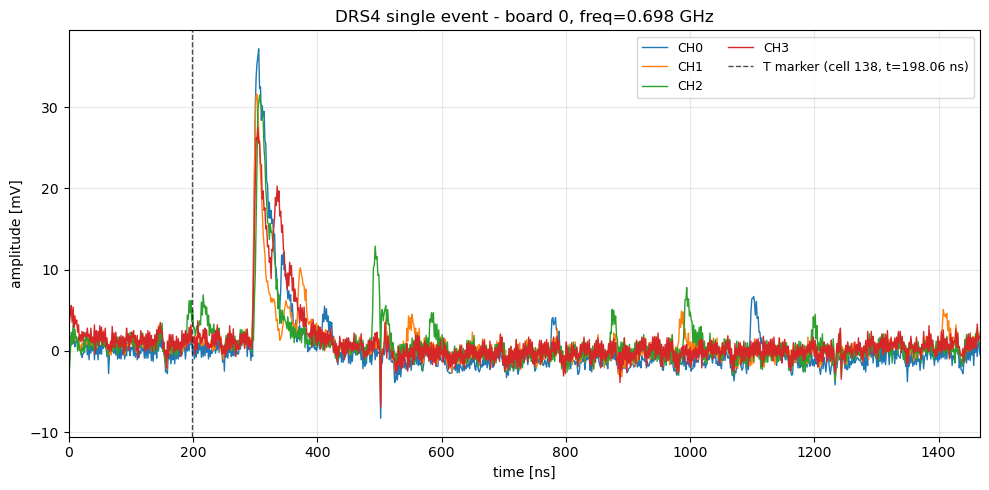

In [8]:
# ---- 1. Single event, all 4 channels overlaid ----
fig, ax = plt.subplots()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for c in range(n_ch):
    ax.plot(t0[c], w0[c], color=colors[c], lw=1.0, label=f"CH{c}")

# T marker = trigger_cell, in sample index.  Convert to time via the time array.
t_marker_time = t0[0, tc0]
ax.axvline(t_marker_time, color="k", ls="--", lw=1.0, alpha=0.7,
           label=f"T marker (cell {tc0}, t={t_marker_time:.2f} ns)")

ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [mV]")
ax.set_title(f"DRS4 single event - board {int(brd_e[0])}, freq={freq_e[0]:.3f} GHz")
ax.set_xlim(0, total_ns)
ax.legend(loc="best", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

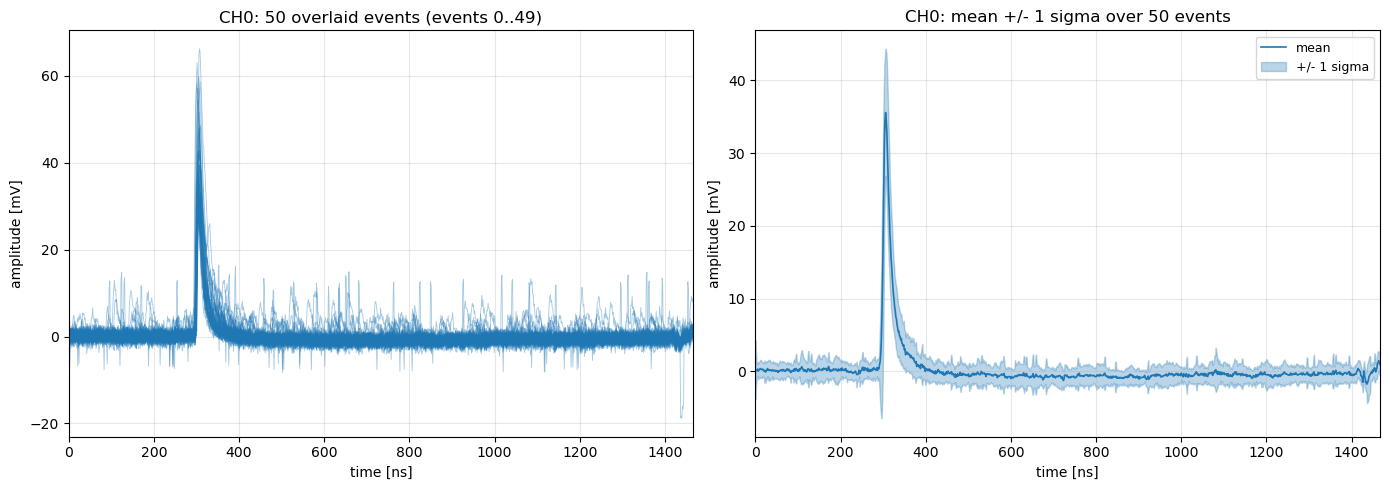

In [15]:
# ---- 2. Many events for one channel, overlaid (jitter / average view) ----
CHAN = 0                  # which physical channel to inspect
N_OVERLAY = 50            # how many events to overlay
EV0 = 0                   # starting event index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay N events
ax = axes[0]
for k in range(N_OVERLAY):
    ev = EV0 + k
    t_ev, w_ev, tc_ev = load_event(ev)
    ax.plot(t_ev[CHAN], w_ev[CHAN], color=colors[CHAN], lw=0.6, alpha=0.4)
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [mV]")
ax.set_title(f"CH{CHAN}: {N_OVERLAY} overlaid events (events {EV0}..{EV0 + N_OVERLAY - 1})")
ax.set_xlim(0, total_ns)

# Right: average of the same N events, with +/- 1 sigma band
ax = axes[1]
waves = np.empty((N_OVERLAY, t0.shape[1]), dtype=np.float32)
times = np.empty((N_OVERLAY, t0.shape[1]), dtype=np.float32)
for k in range(N_OVERLAY):
    t_ev, w_ev, _ = load_event(EV0 + k)
    waves[k] = w_ev[CHAN]
    times[k] = t_ev[CHAN]
mean = waves.mean(axis=0)
std  = waves.std(axis=0)
t_ref = times[0]   # time axis is invariant across events
ax.plot(t_ref, mean, color=colors[CHAN], lw=1.2, label="mean")
ax.fill_between(t_ref, mean - std, mean + std, color=colors[CHAN], alpha=0.3, label="+/- 1 sigma")
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [mV]")
ax.set_title(f"CH{CHAN}: mean +/- 1 sigma over {N_OVERLAY} events")
ax.set_xlim(0, total_ns)
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

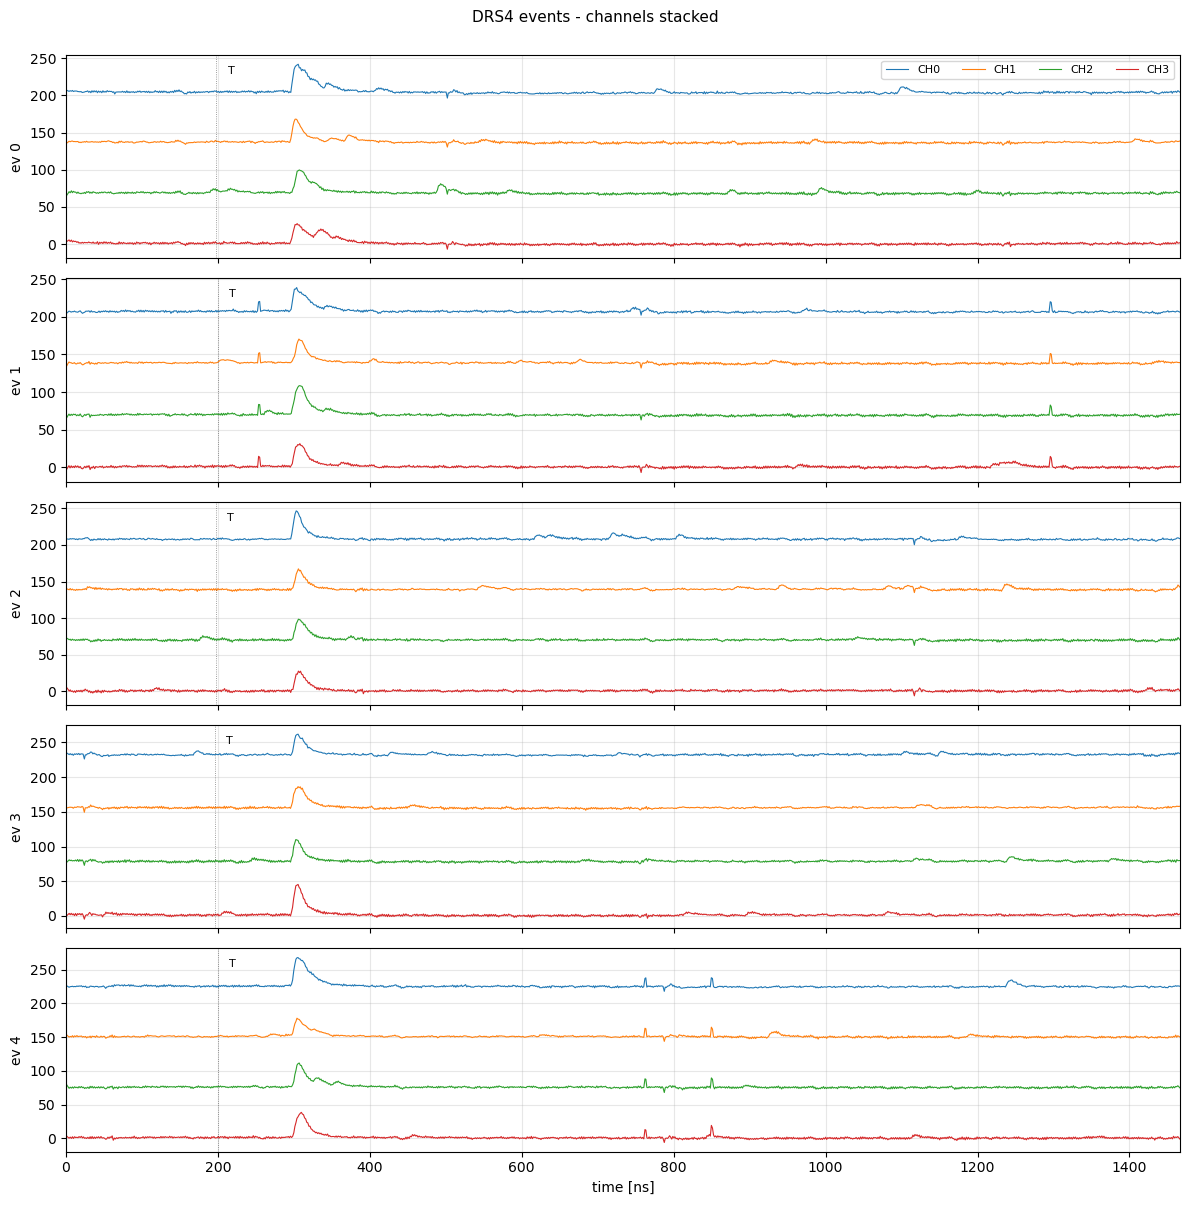

In [17]:
# ---- 3. Grid of small multiples: first N events, channels stacked ----
N_EVENTS_GRID = 5
fig, axes = plt.subplots(N_EVENTS_GRID, 1, figsize=(12, 2.4 * N_EVENTS_GRID), sharex=True)
if N_EVENTS_GRID == 1:
    axes = [axes]
for row, ev in enumerate(range(N_EVENTS_GRID)):
    t_ev, w_ev, tc_ev = load_event(ev)
    ax = axes[row]
    # Offset each channel vertically for clarity
    span = float(np.ptp(w_ev))
    offsets = np.arange(n_ch)[::-1] * (span * 1.5) if span > 0 else np.zeros(n_ch)
    for c in range(n_ch):
        ax.plot(t_ev[c], w_ev[c] + offsets[c], color=colors[c], lw=0.8, label=f"CH{c}")
    t_marker_time = t_ev[0, tc_ev]
    ax.axvline(t_marker_time, color="k", ls=":", lw=0.6, alpha=0.5)
    ax.text(t_marker_time + total_ns * 0.01, ax.get_ylim()[1] * 0.9, "T", fontsize=8)
    ax.set_ylabel(f"ev {ev}")
    if row == 0:
        ax.legend(loc="upper right", fontsize=8, ncol=4)
axes[-1].set_xlabel("time [ns]")
for ax in axes:
    ax.set_xlim(0, total_ns)
fig.suptitle("DRS4 events - channels stacked", y=1.0, fontsize=11)
plt.tight_layout()
plt.show()

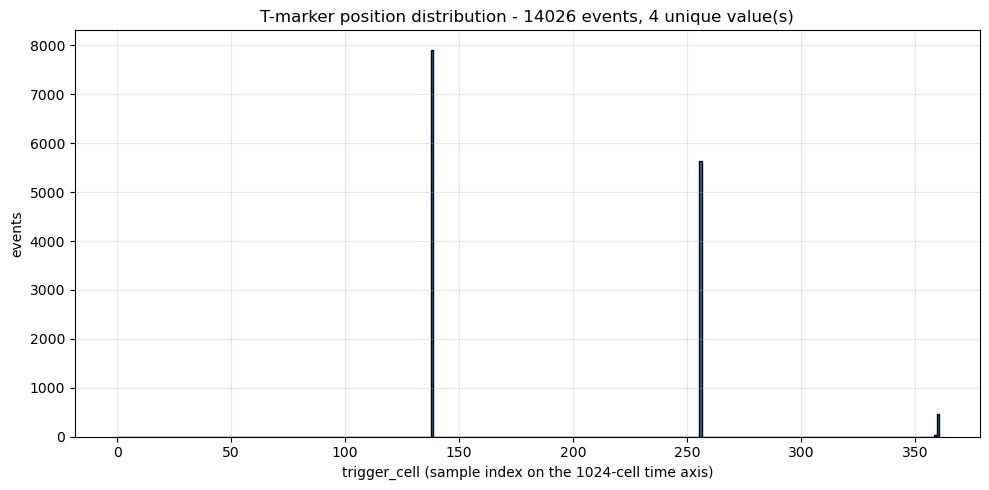

T-marker values seen: [138, 256, 359, 360]


In [11]:
# ---- 4. Trigger-cell distribution (sanity check on trigger delay setting) ----
fig, ax = plt.subplots()
ax.hist(tc_e, bins=np.arange(-0.5, np.max(tc_e) + 1.5, 1.0), color="#1f77b4", edgecolor="k")
ax.set_xlabel("trigger_cell (sample index on the 1024-cell time axis)")
ax.set_ylabel("events")
ax.set_title(f"T-marker position distribution - {n_events} events, {len(np.unique(tc_e))} unique value(s)")
plt.tight_layout()
plt.show()

# If only one value, that means trigger delay was held fixed during the run.
print(f"T-marker values seen: {sorted(np.unique(tc_e).tolist())}")
if len(np.unique(tc_e)) == 1:
    delay_ns = t0[0, int(np.unique(tc_e)[0])]
    print(f"-> fixed trigger delay = {delay_ns:.2f} ns on the time axis")